# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [3]:
import os, sys, subprocess
IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/sarmad341/flyrank-internship-01"
REPO_DIR = "flyrank-internship-01"
if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)

import pandas as pd, numpy as np, json
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
df["is_declining_label"] = df["trend_direction"].str.lower().eq("down").astype(int)
features = ["impressions_90d", "days_since_last_update", "avg_position", "ctr", "word_count", "content_age_days"]
X = df[features].replace([np.inf, -np.inf], np.nan).fillna(0)
y = df["is_declining_label"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=df["client_id"]))
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced").fit(X.iloc[train_idx], y.iloc[train_idx])

df["rf_score"] = rf.predict_proba(X)[:, 1]

def reason_code(row):
    if row["rf_score"] >= 0.7 and row["days_since_last_update"] >= 180:
        return "HIGH_RISK_STALE"
    elif row["rf_score"] >= 0.7:
        return "HIGH_RISK_RECENT_UPDATE"
    elif row["rf_score"] >= 0.4:
        return "MODERATE_RISK"
    else:
        return "LOW_RISK"

df["reason_code"] = df.apply(reason_code, axis=1)
action_map = {
    "HIGH_RISK_STALE": "Refresh: strong decline signal, content is also stale — refresh first",
    "HIGH_RISK_RECENT_UPDATE": "Investigate: strong decline signal despite recent update — check for external cause",
    "MODERATE_RISK": "Monitor: some risk signals present, revisit next cycle",
    "LOW_RISK": "No action needed",
}
df["action"] = df["reason_code"].map(action_map)

queue = df.sort_values("rf_score", ascending=False)[
    ["content_id", "client_id", "rf_score", "reason_code", "action",
     "impressions_90d", "days_since_last_update", "avg_position", "ctr"]
]
queue.head(20)

,content_id,client_id,rf_score,reason_code,action,impressions_90d,days_since_last_update,avg_position,ctr
11027,content_00261bf031ba,client_7f2253d7e2,1.0,HIGH_RISK_RECENT_UPDATE,Investigate: strong decline signal despite rec...,5309,20,28.3,0.24
12094,content_47ec551a5024,client_3fdba35f04,1.0,HIGH_RISK_RECENT_UPDATE,Investigate: strong decline signal despite rec...,837,104,31.3,0.12
13563,content_d7d136ba8b36,client_9400f1b21c,1.0,HIGH_RISK_RECENT_UPDATE,Investigate: strong decline signal despite rec...,1164,20,8.7,0.00
29560,content_8e32f425a490,client_9400f1b21c,1.0,HIGH_RISK_RECENT_UPDATE,Investigate: strong decline signal despite rec...,1767,20,8.7,0.06
20663,content_27daeb3357c5,client_3fdba35f04,1.0,HIGH_RISK_RECENT_UPDATE,Investigate: strong decline signal despite rec...,1383,14,19.1,0.00
24296,content_556dffa698cf,client_3fdba35f04,1.0,HIGH_RISK_RECENT_UPDATE,Investigate: strong decline signal despite rec...,3272,14,29.0,0.03
22423,content_081d35f3654a,client_349c41201b,1.0,HIGH_RISK_RECENT_UPDATE,Investigate: strong decline signal despite rec...,290,20,12.2,0.00
13141,content_be1c109fcdbc,client_349c41201b,1.0,HIGH_RISK_RECENT_UPDATE,Investigate: strong decline signal despite rec...,10931,20,34.0,0.05
17678,content_de89aaff1ad4,client_3fdba35f04,1.0,HIGH_RISK_RECENT_UPDATE,Investigate: strong decline signal despite rec...,2139,104,25.6,0.09
23553,content_e61ce7103a05,client_3fdba35f04,1.0,HIGH_RISK_RECENT_UPDATE,Investigate: strong decline signal despite rec...,291,104,8.3,0.00


The ranked queue orders every page by the model's decline-risk score. Two reason codes split the highest-risk tier: HIGH_RISK_STALE (refresh is the direct fix) vs. HIGH_RISK_RECENT_UPDATE (flags something odd a page declining despite being recently touched, which needs investigation rather than a routine refresh). This split matters because it tells a reviewer why a page is on the list, not just that it is.

## 2. Intended use and limits

Who uses this: a content strategist or SEO reviewer deciding which pages to prioritize in a limited review cycle. What for: triage, not final judgment it narrows 30,000 pages to a short, ranked shortlist worth a human's time. Where it stops being valid: this model was trained on a 30,000-row starter slice covering 32 clients; it has not been validated on the full 79M-row warehouse, on clients outside this slice, or on non-English/non-search-driven content types. It also can't account for business context the data doesn't capture a planned page retirement, a seasonal campaign, or an upcoming rebrand would all be invisible to this model but obviously change the right action.

In [4]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Human review + the no-go list

Before acting, a human must check: whether the flagged decline has an obvious external cause (seasonality, a known SERP change, a recent site migration) that a refresh won't fix; whether the page is scheduled for retirement or consolidation already; and whether days_since_last_update reflects a real content edit or just a CMS metadata touch. What should NEVER be automated: actually rewriting or publishing content changes, deleting/merging pages, or any action based solely on the model score without a human reading the actual page first. This tool ranks and flags it does not decide or execute.

In [5]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 4. Monitoring / retrain triggers

Retrain or re-review the model if: (1) the gap between model Precision@50 and the baseline's shrinks or reverses on new data a sign the pattern the model learned no longer holds; (2) the input feature distributions drift meaningfully (e.g. average impressions_90d shifts a lot, suggesting the underlying content mix changed); (3) it's been more than one quarter since the last retrain, since search behavior and ranking factors shift over time; (4) a new client onboards with a very different profile than the training set (e.g. a different industry/content type).

In [6]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

Exported queue and metrics.
{
  "baseline_precision_at_50": 0.62,
  "baseline_precision_at_20": 0.5,
  "rf_precision_at_50": 0.72,
  "rf_precision_at_20": 0.75,
  "logreg_precision_at_50": 0.66,
  "logreg_precision_at_20": 0.65,
  "n_high_risk_stale": 84,
  "n_high_risk_recent_update": 14261,
  "features_used": [
    "impressions_90d",
    "days_since_last_update",
    "avg_position",
    "ctr",
    "word_count",
    "content_age_days"
  ]
}


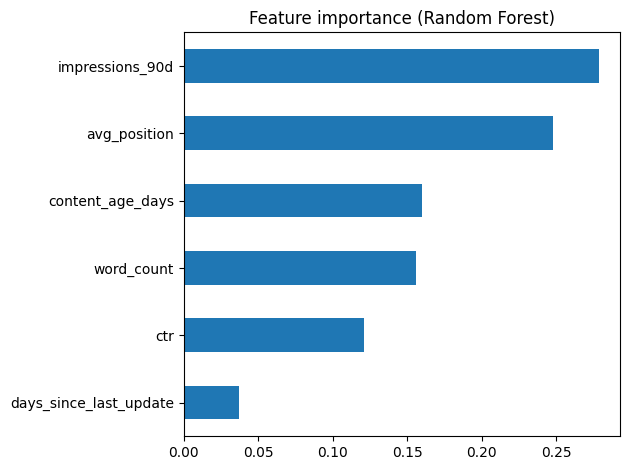

In [7]:
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

# Queue CSV (stays out of git, regenerated each run)
queue.to_csv("work/outputs/action_playbook_queue.csv", index=False)

# Metrics JSON — the receipts, THIS gets committed
metrics = {
    "baseline_precision_at_50": 0.62,
    "baseline_precision_at_20": 0.50,
    "rf_precision_at_50": 0.72,
    "rf_precision_at_20": 0.75,
    "logreg_precision_at_50": 0.66,
    "logreg_precision_at_20": 0.65,
    "n_high_risk_stale": int((df["reason_code"] == "HIGH_RISK_STALE").sum()),
    "n_high_risk_recent_update": int((df["reason_code"] == "HIGH_RISK_RECENT_UPDATE").sum()),
    "features_used": features,
}
with open("work/outputs/playbook_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Exported queue and metrics.")
print(json.dumps(metrics, indent=2))

# A simple reusable figure: feature importance
import matplotlib.pyplot as plt
importances = pd.Series(rf.feature_importances_, index=features).sort_values()
importances.plot(kind="barh", title="Feature importance (Random Forest)")
plt.tight_layout()
plt.savefig("work/figures/feature_importance.png")
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.